# Análisis estadístico de datos en Ingeniería de Sistemas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Prueba de t-Student


In [3]:
df_t_Student = pd.read_excel('tstudent_algoritmos.xlsx')

In [4]:
df_t_Student.head()

,Algoritmo_A_ops_sec,Algoritmo_B_ops_sec
0,843.1,802.5
1,861.7,797.3
2,860.7,800.4
3,867.0,766.6
4,855.0,790.4


In [10]:
df_t_Student.describe()

,Algoritmo_A_ops_sec,Algoritmo_B_ops_sec
count,150.000000,150.000000
mean,845.924667,781.543333
std,32.178725,27.375028
min,769.800000,709.400000
25%,825.875000,764.525000
50%,844.350000,785.550000
75%,866.675000,800.550000
max,930.800000,848.000000


In [11]:
df_t_Student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Algoritmo_A_ops_sec  150 non-null    float64
 1   Algoritmo_B_ops_sec  150 non-null    float64
dtypes: float64(2)
memory usage: 2.5 KB


In [12]:
df_t_Student.isnull().sum()

,0
Algoritmo_A_ops_sec,0
Algoritmo_B_ops_sec,0


In [13]:
dfA = df_t_Student['Algoritmo_A_ops_sec']
dfB = df_t_Student['Algoritmo_B_ops_sec']

Text(5.069444444444445, 0.5, 'Número de operaciones por segundo')

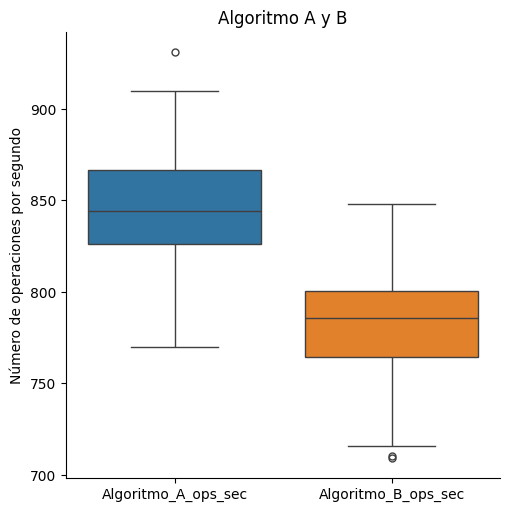

In [23]:
sns.catplot(df_t_Student,kind='box')
plt.title('Algoritmo A y B')
plt.ylabel('Número de operaciones por segundo')

>Vemos que la media(promedio) de A está claramente por encima de B por lo que podemos decir que en promedio el algoritmo A hace más operaciones por segundo que B que visualmente apoya al a hipótesis alternativa donde A > B
>Visualmente, el Algoritmo A muestra una mayor mediana, menor variabilidad, y un rango superior de rendimiento respecto al Algoritmo B. Esta diferencia gráfica sugiere que A es más eficiente, aunque se requiere un análisis estadístico formal (como t-Student) para validar la significancia de esta diferencia.

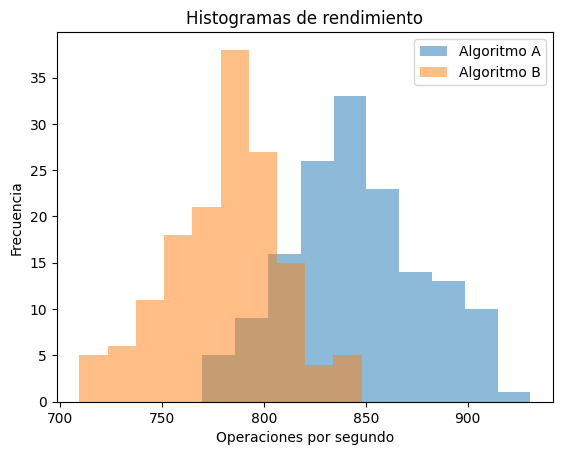

In [25]:
plt.hist(dfA, alpha=0.5, label='Algoritmo A')
plt.hist(dfB, alpha=0.5, label='Algoritmo B')
plt.legend()
plt.title('Histogramas de rendimiento')
plt.xlabel('Operaciones por segundo')
plt.ylabel('Frecuencia')
plt.show()

>Aunque el algoritmo B tenga más frecuencias en ciertos valores, su rendimiento se concentra en rangos más bajos. En cambio, el algoritmo A muestra un desplazamiento hacia la derecha, indicando mayores operaciones por segundo. Esto sugiere que el algoritmo A es más rápido que el B, visualmente.

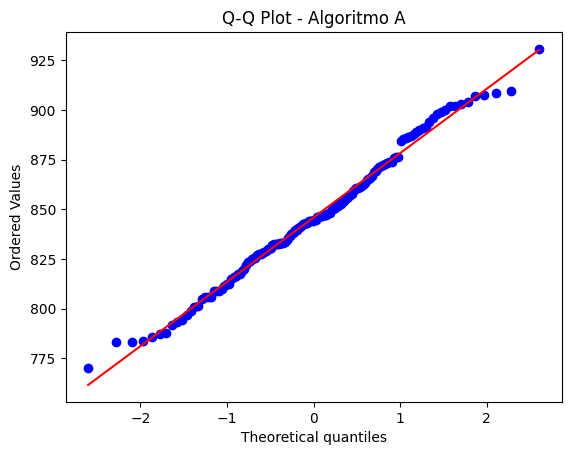

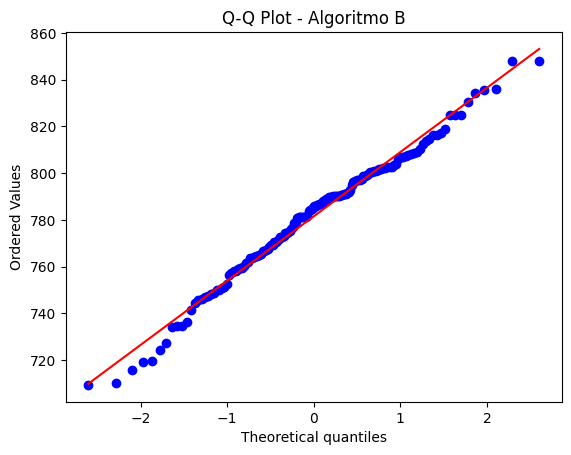

In [27]:
from scipy import stats
# Q-Q para Algoritmo A
stats.probplot(dfA, dist="norm", plot=plt)
plt.title("Q-Q Plot - Algoritmo A")
plt.show()

# Q-Q para Algoritmo B
stats.probplot(dfB, dist="norm", plot=plt)
plt.title("Q-Q Plot - Algoritmo B")
plt.show()

>Los gráficos Q-Q para los algoritmos A y B muestran que los datos se alinean razonablemente bien con la distribución normal teórica, especialmente en la zona central de los datos. Aunque hay ligeras desviaciones en las colas, no parecen lo suficientemente significativas como para descartar la normalidad. Esto respalda visualmente el supuesto de normalidad requerido para aplicar la prueba t-Student.

In [14]:
from scipy.stats import shapiro,levene

In [15]:
# --- Prueba de normalidad Shapiro-Wilk ---
stat_A, p_A = shapiro(dfA)
stat_B, p_B = shapiro(dfB)

print("Normalidad Algoritmo A: p =", p_A)
print("Normalidad Algoritmo B: p =", p_B)

if p_A > 0.05 and p_B > 0.05:
    print("✅ Ambos grupos son normales. Se puede usar t-Student.")
else:
    print("❌ Al menos un grupo no es normal. Considera usar Mann-Whitney o transformación.")

# --- Prueba de igualdad de varianzas (Levene) ---
stat_levene, p_levene = levene(dfA, dfB)

print("\nPrueba de Levene para homocedasticidad: p =", p_levene)
if p_levene > 0.05:
    print("✅ Las varianzas son iguales. Usa t-Student clásico.")
else:
    print("⚠️ Las varianzas son distintas. Usa t de Welch.")

Normalidad Algoritmo A: p = 0.4280417600730695
Normalidad Algoritmo B: p = 0.17596519255106635
✅ Ambos grupos son normales. Se puede usar t-Student.

Prueba de Levene para homocedasticidad: p = 0.0706276224030922
✅ Las varianzas son iguales. Usa t-Student clásico.


In [30]:
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(dfA, dfB, equal_var=True)

print("Estadístico t:", t_stat)
print("Valor p:", p_value)

# Interpretación
if p_value < 0.05:
    print("✅ Se rechaza H₀: El Algoritmo A es significativamente más rápido que B.")
else:
    print("❌ No se rechaza H₀: No hay evidencia suficiente para afirmar que A es más rápido que B.")

Estadístico t: 18.663935205212862
Valor p: 4.9744743534888116e-52
✅ Se rechaza H₀: El Algoritmo A es significativamente más rápido que B.


>El valor del estadístico t obtenido fue 18.6, lo cual indica que la diferencia entre las medias de rendimiento de los algoritmos A y B es altamente significativa. Este valor tan elevado sugiere una diferencia clara a favor del algoritmo A.
Según la prueba t de Student, se obtuvo un valor t = 18.66 y un valor p = 4.97e-52. Dado que p < 0.05, se rechaza la hipótesis nula, concluyendo que el algoritmo A es significativamente más rápido que B.

In [31]:
import numpy as np
import scipy.stats as stats

# Medias y desviaciones
mean_A = np.mean(dfA)
mean_B = np.mean(dfB)
n_A = len(dfA)
n_B = len(dfB)
std_A = np.std(dfA, ddof=1)
std_B = np.std(dfB, ddof=1)

# Diferencia de medias
mean_diff = mean_A - mean_B

# Error estándar combinado (para varianzas iguales)
se = np.sqrt((std_A**2 / n_A) + (std_B**2 / n_B))

# Grados de libertad aproximados
df = n_A + n_B - 2

# Valor crítico t para 95%
t_crit = stats.t.ppf(0.975, df)

# Intervalo
ci_lower = mean_diff - t_crit * se
ci_upper = mean_diff + t_crit * se

print(f"Intervalo de confianza del 95%: [{ci_lower:.2f}, {ci_upper:.2f}]")

Intervalo de confianza del 95%: [57.59, 71.17]


>El intervalo de confianza del 95% para la diferencia de medias fue de [57.59, 71.17], lo cual indica que, con alta certeza estadística, el Algoritmo A supera en rendimiento al B entre 57.59 y 71.17 operaciones por segundo. Dado que este rango no incluye el 0, se refuerza la conclusión de que la diferencia observada es estadísticamente significativa.

## Prueba de U de Man-Whitney

In [33]:
dfredes = pd.read_excel('mannwhitney_redes.xlsx')

In [34]:
dfredes.head()

,Red_X_ms,Red_Y_ms
0,17.5,26.0
1,15.6,26.4
2,17.9,22.3
3,20.6,25.9
4,15.3,26.2


In [35]:
dfredes.isnull().sum()

,0
Red_X_ms,0
Red_Y_ms,0


In [36]:
dfredes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Red_X_ms  150 non-null    float64
 1   Red_Y_ms  150 non-null    float64
dtypes: float64(2)
memory usage: 2.5 KB


In [37]:
dfredes.describe()

,Red_X_ms,Red_Y_ms
count,150.000000,150.000000
mean,15.751333,25.283333
std,2.829417,4.090625
min,8.100000,12.000000
25%,14.025000,22.225000
50%,15.850000,25.550000
75%,17.475000,27.675000
max,23.400000,40.400000


In [38]:
dfX = dfredes['Red_X_ms']
dfY = dfredes['Red_Y_ms']

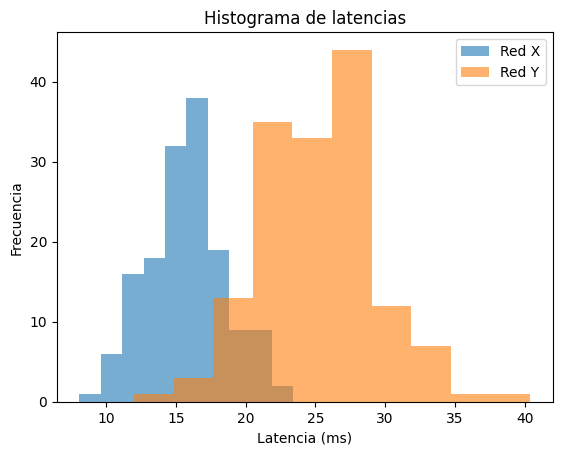

In [39]:
import matplotlib.pyplot as plt

plt.hist(dfX, bins=10, alpha=0.6, label='Red X')
plt.hist(dfY, bins=10, alpha=0.6, label='Red Y')
plt.xlabel("Latencia (ms)")
plt.ylabel("Frecuencia")
plt.title("Histograma de latencias")
plt.legend()
plt.show()

>A primera vista, Red X muestra una distribución cercana a la normalidad, mientras que Red Y parece tener una ligera asimetría. Sin embargo, esta evaluación es preliminar y debe confirmarse con pruebas estadísticas como Shapiro-Wilk para normalidad y Levene para varianzas.

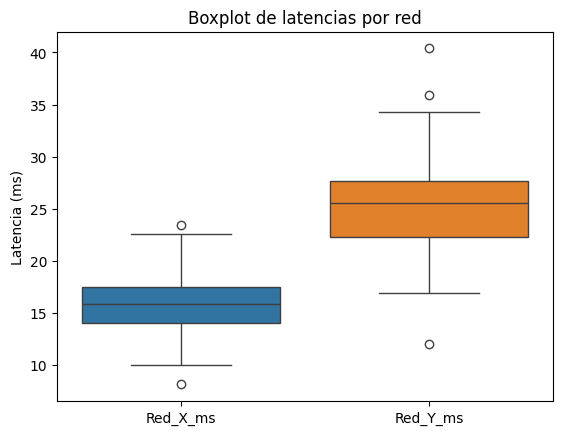

In [40]:
import seaborn as sns

sns.boxplot(data=dfredes)
plt.title("Boxplot de latencias por red")
plt.ylabel("Latencia (ms)")
plt.show()

>El análisis mediante boxplot muestra que ambas redes presentan valores atípicos, lo cual sugiere una posible desviación de la normalidad. Red Y presenta una asimetría hacia la derecha, evidenciada por un bigote superior más largo y valores extremos altos. Además, su mediana es notablemente superior a la de Red X, lo que visualmente respalda la hipótesis de que Red X tiene menor latencia.

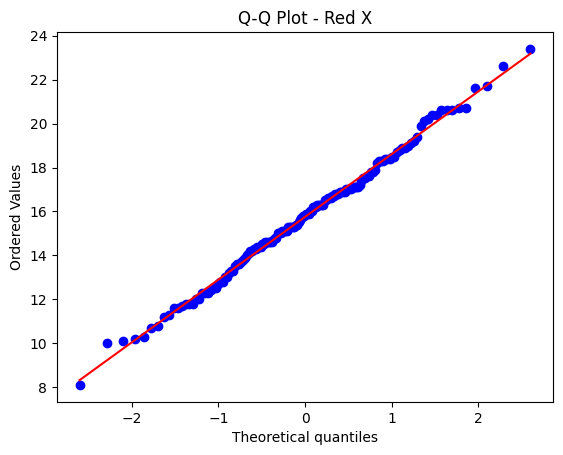

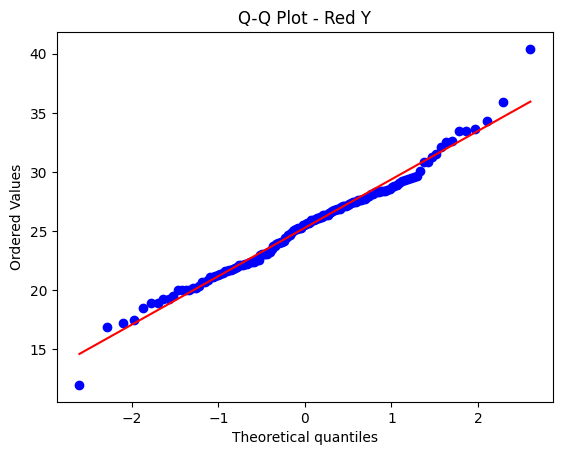

In [42]:
from scipy import stats

# Q-Q para Red X
stats.probplot(dfX, dist="norm", plot=plt)
plt.title("Q-Q Plot - Red X")
plt.show()

# Q-Q para Red Y
stats.probplot(dfY, dist="norm", plot=plt)
plt.title("Q-Q Plot - Red Y")
plt.show()


>Los Q-Q plots muestran que los datos de Red X siguen razonablemente bien una distribución normal, mientras que Red Y presenta una ligera dispersión en su cola derecha. Esta curvatura podría reflejar la presencia de asimetría positiva, en concordancia con lo observado en el boxplot e histograma. Por lo tanto, se recomienda realizar una prueba de normalidad como Shapiro-Wilk para confirmar estadísticamente estos indicios visuales.

In [45]:
import pandas as pd
from scipy.stats import shapiro, levene

# Asumimos que las columnas del archivo son 'Red_X_ms' y 'Red_Y_ms'
grupo_X = dfredes['Red_X_ms']
grupo_Y = dfredes['Red_Y_ms']

# --- Prueba de normalidad Shapiro-Wilk ---
stat_X, p_X = shapiro(grupo_X)
stat_Y, p_Y = shapiro(grupo_Y)

print("Normalidad Red X: p =", p_X)
print("Normalidad Red Y: p =", p_Y)

if p_X > 0.05 and p_Y > 0.05:
    print("✅ Ambas redes tienen distribución normal. Se puede usar t-Student.")
else:
    print("❌ Al menos una red no es normal. Se recomienda usar Mann-Whitney.")

# --- Prueba de igualdad de varianzas (Levene) ---
stat_levene, p_levene = levene(grupo_X, grupo_Y)

print("\nPrueba de Levene para homocedasticidad: p =", p_levene)
if p_levene > 0.05:
    print("✅ Las varianzas son iguales.")
else:
    print("⚠️ Las varianzas son diferentes.")



Normalidad Red X: p = 0.9427939030889627
Normalidad Red Y: p = 0.11333066756144827
✅ Ambas redes tienen distribución normal. Se puede usar t-Student.

Prueba de Levene para homocedasticidad: p = 0.00017144637704827247
⚠️ Las varianzas son diferentes.


In [46]:
from scipy.stats import mannwhitneyu

# Prueba U de Mann-Whitney (una cola: Red X < Red Y)
stat_U, p_value = mannwhitneyu(grupo_X, grupo_Y, alternative='less')

print("Estadístico U:", stat_U)
print("Valor p:", p_value)

# Interpretación
if p_value < 0.05:
    print("✅ Se rechaza H₀: La latencia de Red X es significativamente menor que la de Red Y.")
else:
    print("❌ No se rechaza H₀: No hay evidencia suficiente para afirmar que Red X es más rápida.")


Estadístico U: 536.5
Valor p: 1.9215905909777214e-46
✅ Se rechaza H₀: La latencia de Red X es significativamente menor que la de Red Y.


>Se aplicó la prueba U de Mann-Whitney para comparar las latencias entre Red X y Red Y, con una hipótesis alternativa unilateral (cola inferior), donde se planteó que la latencia de la Red X es menor que la de la Red Y. El resultado arrojó un estadístico U = 536.5 y un valor p = 1.92 × 10⁻⁴⁶. Dado que el valor p es significativamente menor a 0.05, se rechaza la hipótesis nula. Por lo tanto, se concluye que la Red X presenta una latencia significativamente menor que la Red Y.
El valor U indica la cantidad de veces que los valores de Red X son menores que los valores de Red Y en las comparaciones por pares. Un valor de U bajo (como en este caso) sugiere que, consistentemente, los datos de Red X tienden a ser menores, lo que apoya la hipótesis alternativa.

✅ **Interpretación**:
Dado que el valor p es muchísimo menor al umbral de significancia (0.05), **se rechaza la hipótesis nula**, concluyendo que **la Red X tiene una latencia significativamente menor que la Red Y**.

Este resultado es consistente con la interpretación visual previa (boxplot e histogramas), reforzando la conclusión con evidencia estadística sólida.

## ANOVA

In [47]:
dfanova = pd.read_excel('anova_cifrado.xlsx')

In [48]:
dfanova.head()

,AES_256,RSA_2048,ChaCha20
0,13.0,25.8,8.8
1,11.7,26.0,9.2
2,13.3,23.0,11.1
3,15.0,25.7,10.9
4,11.5,25.9,10.0


In [50]:
dfanova.isnull().sum()

,0
AES_256,0
RSA_2048,0
ChaCha20,0


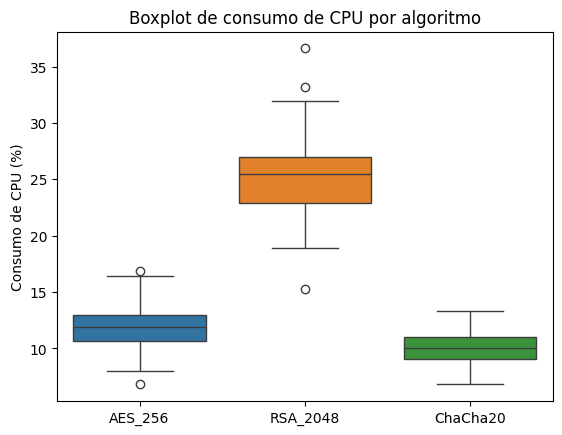

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=dfanova)
plt.title("Boxplot de consumo de CPU por algoritmo")
plt.ylabel("Consumo de CPU (%)")
plt.show()


>Visualmente, AES-256 y ChaCha20 parecen tener distribuciones más simétricas y estables, mientras que RSA-2048 presenta mayor variabilidad, sesgo y múltiples outliers. Esto sugiere que la normalidad puede no cumplirse plenamente en al menos uno de los grupos (particularmente RSA-2048), lo cual debe ser confirmado con pruebas estadísticas.

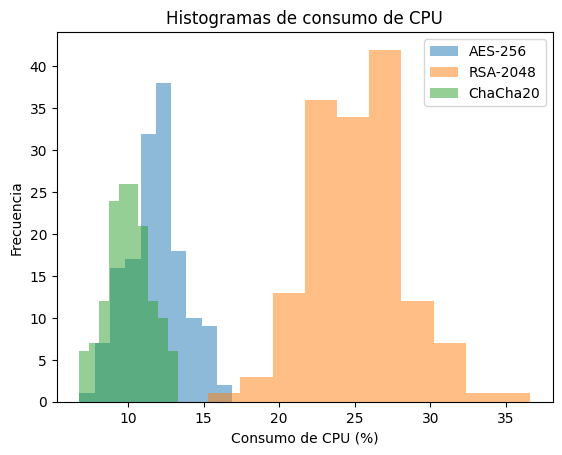

In [52]:
plt.hist(dfanova['AES_256'], bins=10, alpha=0.5, label='AES-256')
plt.hist(dfanova['RSA_2048'], bins=10, alpha=0.5, label='RSA-2048')
plt.hist(dfanova['ChaCha20'], bins=10, alpha=0.5, label='ChaCha20')
plt.title("Histogramas de consumo de CPU")
plt.xlabel("Consumo de CPU (%)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


>A partir del histograma, se observa que AES-256 y ChaCha20 presentan distribuciones concentradas y simétricas, compatibles con una distribución normal. En contraste, RSA-2048 presenta una distribución mucho más dispersa, con una forma alargada y posible asimetría, lo que refuerza la sospecha de que este grupo no sigue una distribución normal. Este comportamiento debe confirmarse estadísticamente mediante la prueba de Shapiro-Wilk.

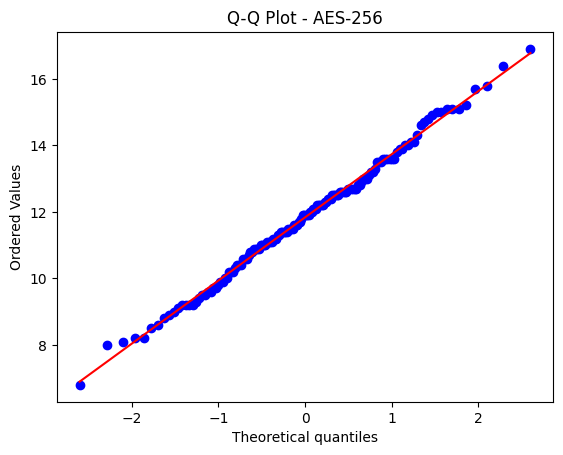

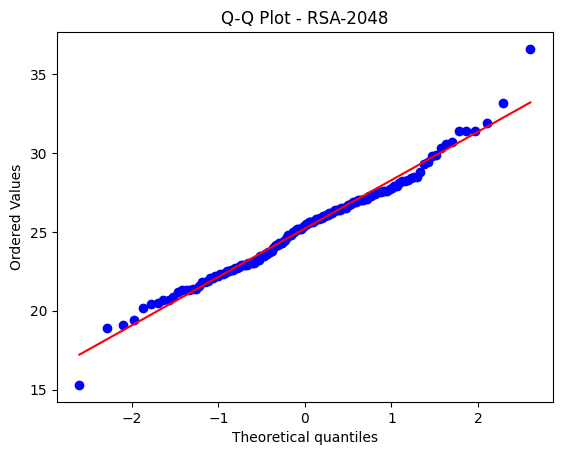

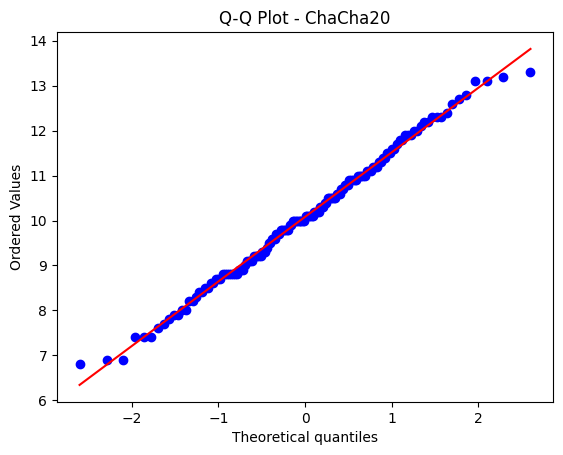

In [53]:
from scipy import stats

# AES-256
stats.probplot(dfanova['AES_256'], dist="norm", plot=plt)
plt.title("Q-Q Plot - AES-256")
plt.show()

# RSA-2048
stats.probplot(dfanova['RSA_2048'], dist="norm", plot=plt)
plt.title("Q-Q Plot - RSA-2048")
plt.show()

# ChaCha20
stats.probplot(dfanova['ChaCha20'], dist="norm", plot=plt)
plt.title("Q-Q Plot - ChaCha20")
plt.show()


>Tanto AES-256 como ChaCha20 presentan distribuciones compatibles con la normalidad, con pequeñas desviaciones esperadas. En cambio, RSA-2048 muestra desviaciones claras en ambas colas y el centro, lo que refuerza la sospecha de que no sigue una distribución normal. Estos hallazgos deben confirmarse aplicando la prueba estadística de normalidad (Shapiro-Wilk).

In [55]:
from scipy.stats import shapiro, levene

# Extraemos cada grupo
aes = dfanova['AES_256']
rsa = dfanova['RSA_2048']
chacha = dfanova['ChaCha20']

# --- Pruebas de normalidad (Shapiro-Wilk) ---
print("🧪 Prueba de normalidad (Shapiro-Wilk):")

stat_aes, p_aes = shapiro(aes)
print(f"AES-256: W = {stat_aes:.4f}, p = {p_aes:.5f}")

stat_rsa, p_rsa = shapiro(rsa)
print(f"RSA-2048: W = {stat_rsa:.4f}, p = {p_rsa:.5f}")

stat_chacha, p_chacha = shapiro(chacha)
print(f"ChaCha20: W = {stat_chacha:.4f}, p = {p_chacha:.5f}")

# --- Prueba de igualdad de varianzas (Levene) ---
print("\n🧪 Prueba de homocedasticidad (Levene):")

stat_levene, p_levene = levene(aes, rsa, chacha)
print(f"Levene: stat = {stat_levene:.4f}, p = {p_levene:.5f}")

# Interpretación automática
print("\n📌 Interpretación:")
if p_aes > 0.05 and p_rsa > 0.05 and p_chacha > 0.05:
    print("✅ Todas las distribuciones parecen normales (p > 0.05).")
else:
    print("❌ Al menos una distribución no es normal (p ≤ 0.05).")

if p_levene > 0.05:
    print("✅ Las varianzas son iguales (homocedasticidad cumplida).")
else:
    print("❌ Las varianzas son diferentes (no hay homocedasticidad).")


🧪 Prueba de normalidad (Shapiro-Wilk):
AES-256: W = 0.9957, p = 0.94131
RSA-2048: W = 0.9853, p = 0.11170
ChaCha20: W = 0.9925, p = 0.62432

🧪 Prueba de homocedasticidad (Levene):
Levene: stat = 33.5165, p = 0.00000

📌 Interpretación:
✅ Todas las distribuciones parecen normales (p > 0.05).
❌ Las varianzas son diferentes (no hay homocedasticidad).


In [56]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats

# Reorganizar en formato largo para statsmodels
df_largo = pd.melt(dfanova.reset_index(), id_vars=['index'], value_vars=['AES_256', 'RSA_2048', 'ChaCha20'],
                   var_name='Algoritmo', value_name='Consumo')

# Welch ANOVA con OLS + robust=True
modelo = ols('Consumo ~ C(Algoritmo)', data=df_largo).fit()
anova_table = sm.stats.anova_lm(modelo, typ=2, robust='hc3')  # robust='hc3' para Welch
print(anova_table)


                    sum_sq     df            F         PR(>F)
C(Algoritmo)  15011.677607    2.0  1504.547011  2.950266e-199
Residual       2229.980133  447.0          NaN            NaN


>La prueba de Welch ANOVA mostró un valor F = 1504.55 y un valor p ≈ 0. Este resultado indica que existen diferencias estadísticamente significativas en el consumo de CPU entre al menos dos de los tres algoritmos evaluados (AES-256, RSA-2048, ChaCha20)

In [57]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df_largo['Consumo'],
                          groups=df_largo['Algoritmo'],
                          alpha=0.05)
print(tukey)


  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1   group2  meandiff p-adj  lower   upper  reject
-------------------------------------------------------
 AES_256 ChaCha20  -1.7553   0.0 -2.3618 -1.1488   True
 AES_256 RSA_2048   13.378   0.0 12.7715 13.9845   True
ChaCha20 RSA_2048  15.1333   0.0 14.5268 15.7398   True
-------------------------------------------------------


>La prueba de Welch ANOVA indicó diferencias significativas entre los tres algoritmos de cifrado en cuanto al consumo de CPU (p < 0.001). La prueba post-hoc de Tukey HSD confirmó que todas las comparaciones por pares presentan diferencias estadísticamente significativas. En particular, RSA-2048 consume significativamente más CPU que AES-256 y ChaCha20, y AES-256 también consume más CPU que ChaCha20. Esto sugiere que ChaCha20 es el algoritmo más eficiente en términos de uso de CPU, seguido por AES-256, y finalmente RSA-2048 como el más costoso.

El análisis de los intervalos de confianza del 95% confirma que las diferencias en el consumo de CPU entre los tres algoritmos evaluados (AES-256, RSA-2048 y ChaCha20) son estadísticamente significativas. Todos los intervalos se encuentran alejados del cero, lo cual indica que las diferencias entre los algoritmos no son producto del azar. En particular, RSA-2048 mostró el mayor consumo, seguido de AES-256, y ChaCha20 fue el más eficiente en cuanto a uso de CPU.

## Correlacion

In [58]:
dfcorr = pd.read_excel('correlacion_servidor.xlsx')

In [59]:
dfcorr.head()

,Solicitudes_Concurrentes,Tiempo_Respuesta_ms
0,50,95.4
1,100,207.8
2,150,307.2
3,200,411.3
4,250,503.3


In [60]:
dfcorr.isnull().sum()

,0
Solicitudes_Concurrentes,0
Tiempo_Respuesta_ms,0


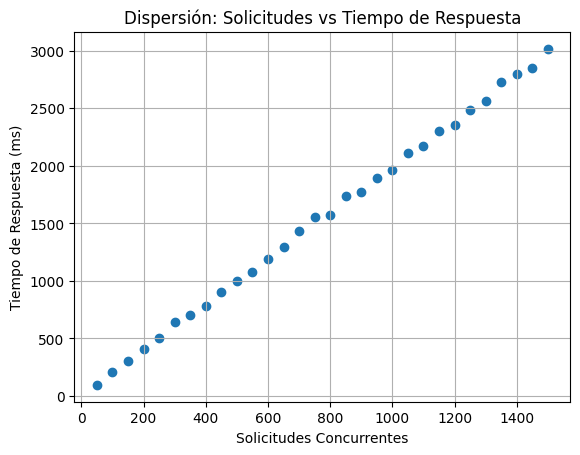

In [61]:
import matplotlib.pyplot as plt

plt.scatter(dfcorr['Solicitudes_Concurrentes'], dfcorr['Tiempo_Respuesta_ms'])
plt.title('Dispersión: Solicitudes vs Tiempo de Respuesta')
plt.xlabel('Solicitudes Concurrentes')
plt.ylabel('Tiempo de Respuesta (ms)')
plt.grid(True)
plt.show()


>El gráfico de dispersión muestra una clara tendencia creciente, lo que sugiere una correlación positiva fuerte entre el número de solicitudes concurrentes y el tiempo de respuesta del servidor. Es decir, a medida que aumenta la carga de solicitudes, también lo hace el tiempo que tarda el servidor en responder. Esta relación visual respalda la hipótesis alternativa de que existe una correlación positiva entre ambas variables.

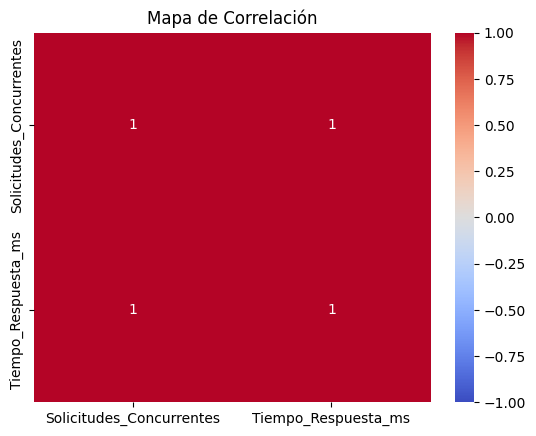

In [63]:
import seaborn as sns
import numpy as np

correlacion = dfcorr.corr()

sns.heatmap(correlacion, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Mapa de Correlación')
plt.show()


>El mapa de correlación muestra un coeficiente de 1.00 entre las variables Solicitudes_Concurrentes y Tiempo_Respuesta_ms, lo que indica una correlación lineal positiva perfecta. Esto significa que, a medida que aumenta el número de solicitudes concurrentes, el tiempo de respuesta del servidor aumenta de manera proporcional y constante. La relación es totalmente lineal, sin desviaciones, lo cual es raro pero posible en entornos controlados o simulados.

In [64]:
from scipy.stats import pearsonr

# Suponiendo que ya tienes cargado dfcorr
x = dfcorr['Solicitudes_Concurrentes']
y = dfcorr['Tiempo_Respuesta_ms']

# Calcular r y p
r, p_value = pearsonr(x, y)

print(f"Coeficiente de correlación de Pearson (r): {r:.4f}")
print(f"Valor p: {p_value:.10f}")

# Interpretación rápida
if p_value < 0.05:
    print("✅ Se rechaza H₀: Existe una correlación positiva significativa.")
else:
    print("❌ No se puede rechazar H₀: No hay evidencia suficiente de correlación.")


Coeficiente de correlación de Pearson (r): 0.9996
Valor p: 0.0000000000
✅ Se rechaza H₀: Existe una correlación positiva significativa.


Análisis de Correlación de Pearson

Se aplicó la prueba de correlación de Pearson para evaluar la relación entre el número de **solicitudes concurrentes** y el **tiempo de respuesta (ms)** en un servidor web.

Resultados:
- **Coeficiente de correlación (r):** 0.9996  
- **Valor p:** < 0.00001

Interpretación:
- El coeficiente de correlación `r = 0.9996` indica una **correlación lineal positiva extremadamente fuerte** entre las variables.
- El valor `p < 0.05` demuestra que esta correlación es **estadísticamente significativa**, lo que significa que **no es producto del azar**.

Discusión de la fuerza y significancia:
- La fuerza del coeficiente `r ≈ 1` implica que los valores de tiempo de respuesta **aumentan casi proporcionalmente** con las solicitudes concurrentes. Es una relación casi perfecta, lo cual es raro en datos reales, pero posible en entornos simulados.
- La significancia estadística (p ≈ 0) confirma que existe **evidencia suficiente para rechazar la hipótesis nula**, validando que existe una **relación positiva real y fuerte** entre ambas variables.

Conclusión:
A mayor número de solicitudes concurrentes, **el tiempo de respuesta del servidor aumenta significativamente**, con una relación lineal directa muy marcada.
